<a href="https://colab.research.google.com/github/mahmooda23/Early-Risk-Stratification-of-Maternal-Complications-during-Pregnancy-/blob/main/predict_risk_during_pregnancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [167]:
import pandas as pd
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [172]:
uploaded = files.upload()
file_name = 'Maternal_Health_Risk_DataSet.csv'
if file_name in uploaded.keys():
  print(f'Successfully uploaded "{file_name}"')


  # Read the CSV file into a pandas DataFrame
  df = pd.read_csv(file_name)
  print("\nFirst 5 rows of the uploaded data:")
  display(df.head())

else:
  print(f'Error: "{file_name}" was not uploaded. Please ensure you select the correct file.')


Saving Maternal_Health_Risk_DataSet.csv to Maternal_Health_Risk_DataSet.csv
Successfully uploaded "Maternal_Health_Risk_DataSet.csv"

First 5 rows of the uploaded data:


,Age,SystolicBP,DiastolicBP,Blood Sugar,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [174]:
df.shape
#df.head(10)

(1014, 7)

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   Blood Sugar  1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [176]:
df.describe()

,Age,SystolicBP,DiastolicBP,Blood Sugar,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [177]:
df.isnull().sum()

,0
Age,0
SystolicBP,0
DiastolicBP,0
Blood Sugar,0
BodyTemp,0
HeartRate,0
RiskLevel,0


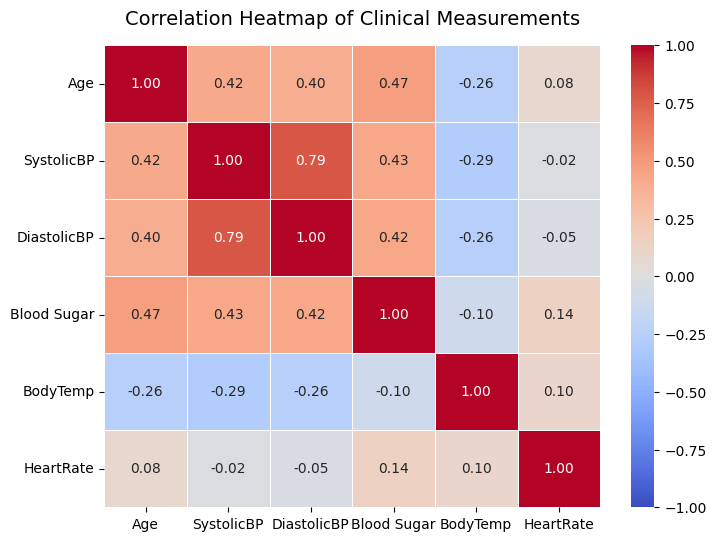

In [178]:
# 1. Correlation Heatmap (Feature-to-Feature)

plt.figure(figsize=(8, 6))

# use numeric_only = True so it ignores the text-based RiskLevel column
correlation_matrix = df.corr(numeric_only=True)

# Generate the heatmap
# annot=True puts the exact correlation numbers inside the squares

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Clinical Measurements', pad=15, fontsize=14)
plt.show()



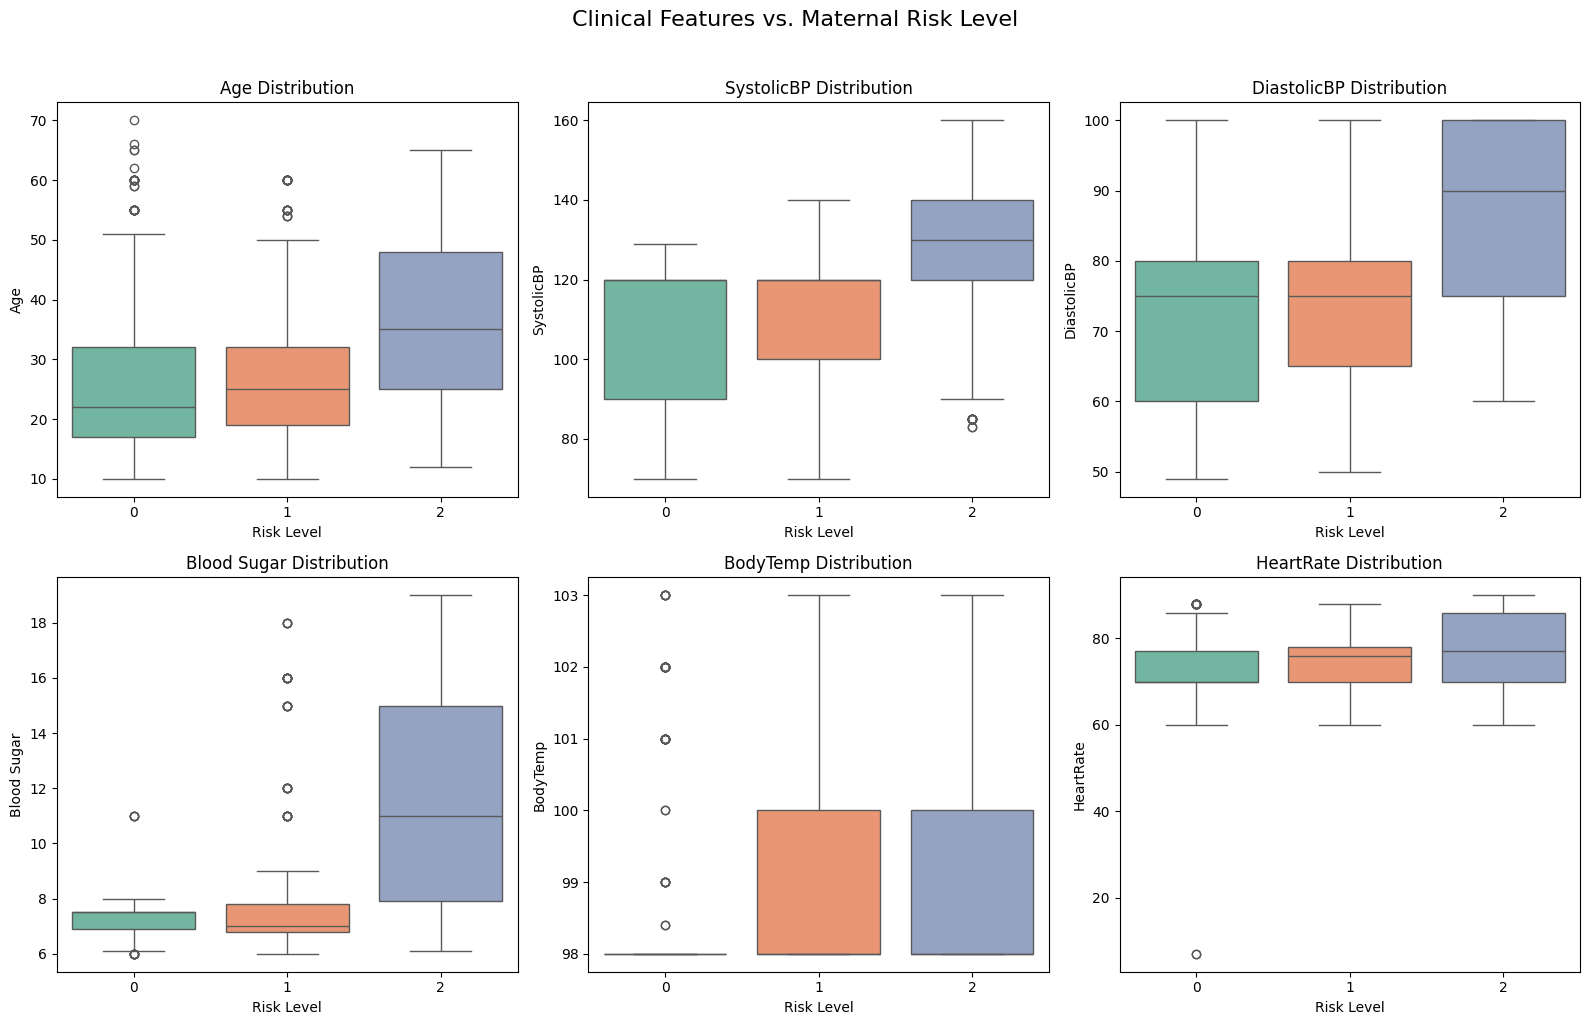

In [181]:
# 2. Boxplots (Feature-to-Target)
# List of 6 numerical columns

# The RiskLevel column is already mapped to numerical values (0, 1, 2) by a previous cell.

features = ['Age', 'SystolicBP', 'DiastolicBP', 'Blood Sugar', 'BodyTemp', 'HeartRate']

# Create a 2x3 grid for the plots so they display cleanly together

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Clinical Features vs. Maternal Risk Level', fontsize=16, y=1.02)

# Flatten the 2D grid of axes into a 1D array so we can loop through it easily

axes = axes.flatten()

# Lock the order from Low to High for clinical readability
# Note: If you already ran your encoding step, change this to: risk_order = [0, 1, 2]

risk_order = [0, 1, 2]

# Loop through each feature and create a boxplot in its respective grid spot

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='RiskLevel', y=feature, order=risk_order, ax=axes[i], palette='Set2', hue='RiskLevel', legend=False)
    axes[i].set_title(f'{feature} Distribution', fontsize=12)
    axes[i].set_ylabel(feature)
    axes[i].set_xlabel('Risk Level')

# Automatically adjust spacing so titles and labels don't overlap
plt.tight_layout()
plt.show()

In [182]:
df['RiskLevel'].value_counts()

,count
RiskLevel,
0,406
1,336
2,272


In [183]:
# Reload the DataFrame to ensure RiskLevel is in its original string format before processing
df = pd.read_csv(file_name)

# Clean the RiskLevel column: strip whitespace and convert to lowercase
df['RiskLevel'] = df['RiskLevel'].str.strip().str.lower()

risk_level_mapping = {
    'low risk': 0,
    'mid risk': 1,
    'high risk': 2
}
df['RiskLevel'] = df['RiskLevel'].map(risk_level_mapping)

print("RiskLevel column after mapping:")
print(df['RiskLevel'].value_counts())
print("\nFirst 5 rows of the DataFrame with numerical RiskLevel:")
display(df.head())

RiskLevel column after mapping:
RiskLevel
0    406
1    336
2    272
Name: count, dtype: int64

First 5 rows of the DataFrame with numerical RiskLevel:


,Age,SystolicBP,DiastolicBP,Blood Sugar,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


In [184]:
# 1. Isolate Features (X) and Target (y)
# X contains all clinical measurements; y contains what I am trying to predict

X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

# 2. Perform the Split
# I use 80% of the data to train the model, and hold back 20% to test it.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# 3. Verify the split (Great to include in a project report)

print(f"Total patients: {len(df)}")
print(f"Patients in Training Set: {len(X_train)}")
print(f"Patients in Testing Set: {len(X_test)}")

Total patients: 1014
Patients in Training Set: 811
Patients in Testing Set: 203


In [186]:
# Initialize a dictionary of 5 different models
# We use class_weight='balanced' wherever possible to protect against class bias

models = {
    "Logistic Regression": LogisticRegression(class_weight ='balanced', max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(class_weight='balanced', probability=True, random_state=42)
}


# 2. Loop through the models, train them, and evaluate them

results = []
print("Training models...")

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the unseen test data
    y_pred = model.predict(X_test)

    # Calculate both Accuracy and Macro Recall
    acc = accuracy_score(y_test, y_pred)
    macro_recall = recall_score(y_test, y_pred, average='macro')

    # Save the results
    results.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Macro Recall (%)": round(macro_recall * 100, 2)
    })

# 3. Create a comparison table and sort it by Macro Recall (the most important metric)
comparison_df = pd.DataFrame(results).sort_values(by="Macro Recall (%)", ascending=False)

print("\n--- Final Model Comparison ---")
print(comparison_df.to_string(index=False))

Training models...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Final Model Comparison ---
                 Model  Accuracy (%)  Macro Recall (%)
         Random Forest         85.71             86.56
     Gradient Boosting         82.76             83.47
         Decision Tree         81.77             83.07
   Logistic Regression         63.05             64.23
Support Vector Machine         60.59             61.47


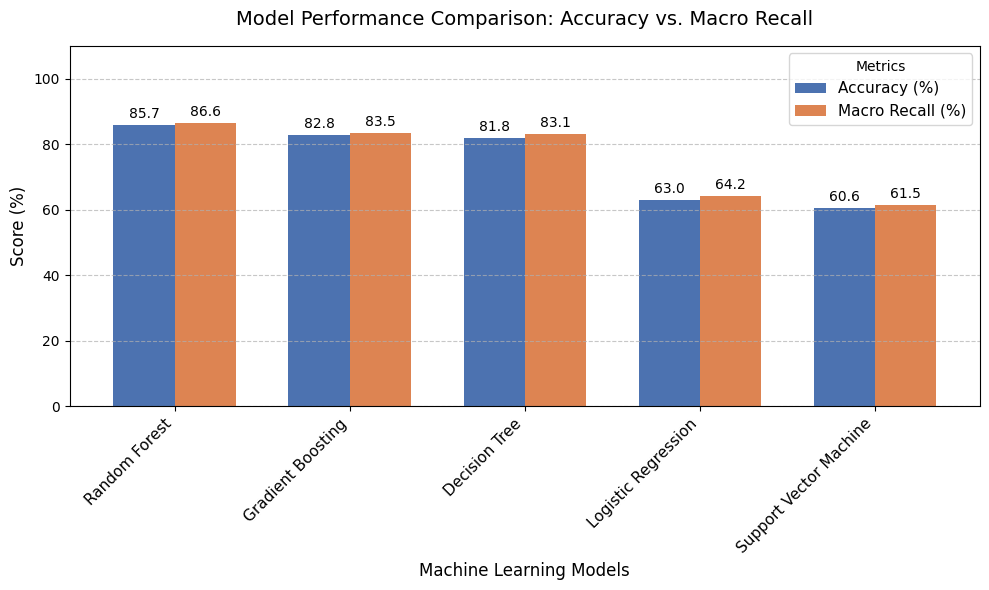

In [187]:
# 1. Set the 'Model' column as the index so it becomes the X-axis labels
plot_df = comparison_df.set_index('Model')

# 2. Create the grouped bar chart
# The pandas .plot() function automatically handles grouping the two columns
ax = plot_df.plot(kind='bar', figsize=(10, 6), width=0.7, color=['#4C72B0', '#DD8452'])

# 3. Add titles and labels
plt.title('Model Performance Comparison: Accuracy vs. Macro Recall', fontsize=14, pad=15)
plt.ylabel('Score (%)', fontsize=12)
plt.xlabel('Machine Learning Models', fontsize=12)

# 4. Formatting to make it presentation-ready
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.ylim(0, 110) # Set Y-axis slightly above 100 to make room for the legend
plt.legend(title='Metrics', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Add the exact numbers on top of the bars for clarity
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

# 6. Adjust layout so the labels don't get cut off, then display
plt.tight_layout()
plt.show()

--- Detailed Clinical Evaluation (Random Forest) ---
              precision    recall  f1-score   support

           0       0.87      0.83      0.85        81
           1       0.81      0.81      0.81        67
           2       0.90      0.96      0.93        55

    accuracy                           0.86       203
   macro avg       0.86      0.87      0.86       203
weighted avg       0.86      0.86      0.86       203



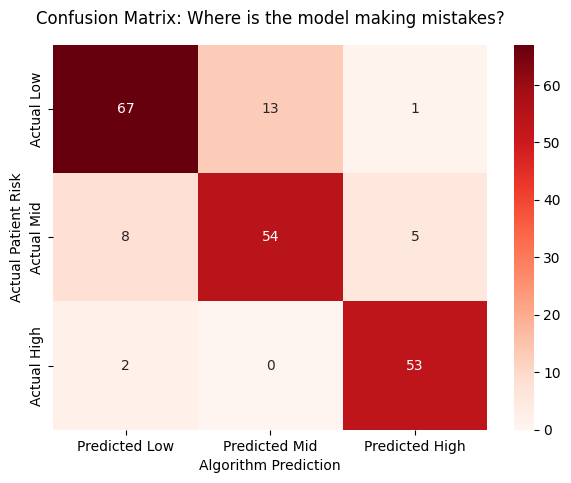

In [194]:
# Assuming 'Random Forest' was the winner from your comparison table
best_model = models["Random Forest"]

# 1. Generate final predictions using the winning model
y_pred_best = best_model.predict(X_test)

# 2. Print the detailed Classification Report
print("--- Detailed Clinical Evaluation (Random Forest) ---")
print(classification_report(y_test, y_pred_best))


# 3. Plot the Confusion Matrix
# FIX: Changed labels to [0, 1, 2] to match your encoded data
cm = confusion_matrix(y_test, y_pred_best, labels=[0, 1, 2])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Low', 'Predicted Mid', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual Mid', 'Actual High'])
plt.title('Confusion Matrix: Where is the model making mistakes?', pad=15)
plt.ylabel('Actual Patient Risk')
plt.xlabel('Algorithm Prediction')
plt.show()


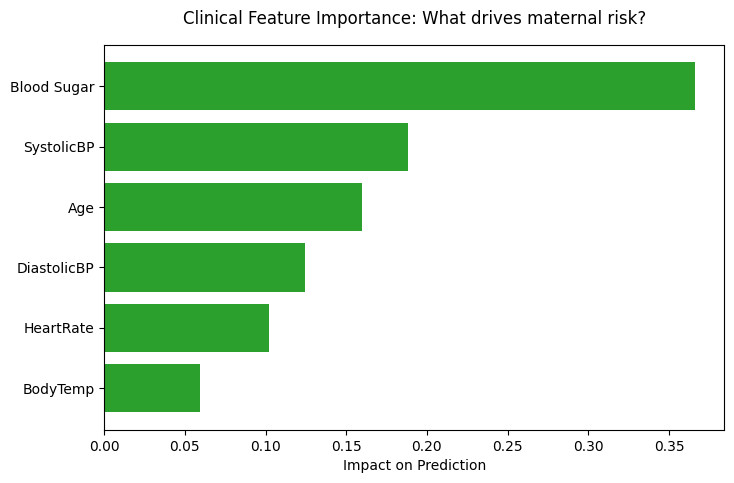

In [193]:

# 4. Plot Clinical Feature Importance

# This explains exactly which clinical metrics drove the predictions
feature_importances = best_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#2ca02c')
plt.title('Clinical Feature Importance: What drives maternal risk?', pad=15)
plt.xlabel('Impact on Prediction')
plt.show()

--- AUC-ROC Analysis for Random Forest ---


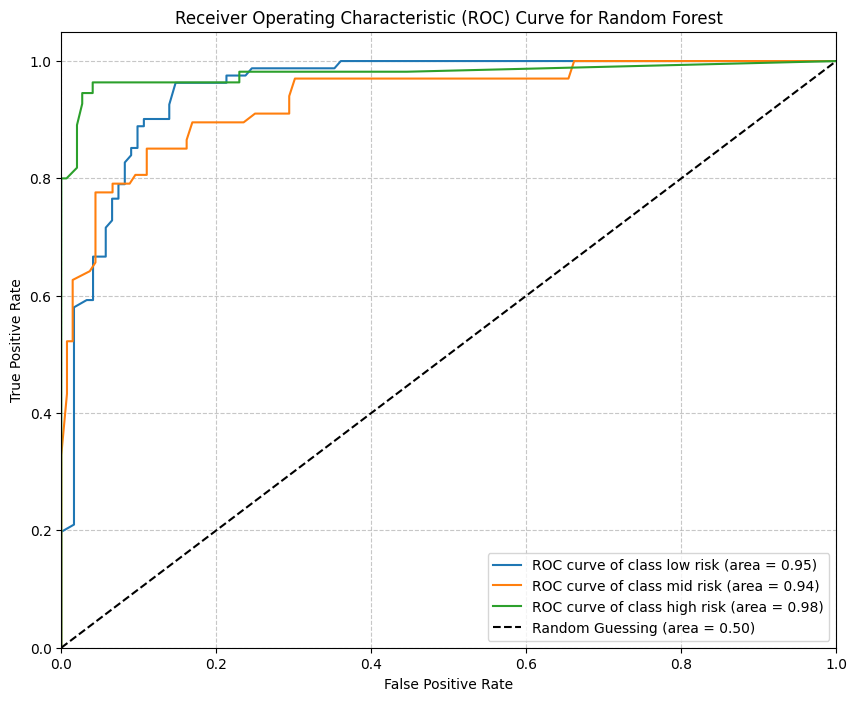

In [192]:
print(f"--- AUC-ROC Analysis for Random Forest ---")

# Get predicted probabilities for each class
y_pred_proba = best_model.predict_proba(X_test)

# Binarize the true labels for multi-class AUC calculation
# Map back to 'low risk', 'mid risk', 'high risk' for correct ordering in label_binarize
risk_level_reverse_mapping = {0: 'low risk', 1: 'mid risk', 2: 'high risk'}
y_test_labels = y_test.map(risk_level_reverse_mapping)
class_labels = ['low risk', 'mid risk', 'high risk']
y_test_binarized = label_binarize(y_test_labels, classes=class_labels)

# Compute ROC curve and AUC for each class
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of class {class_label} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (area = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Random Forest')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()